# Alexiou Stamatios - 2020030158 - Assignment 1

# Exercise 5

## The Unruly Puzzle

The Unruly puzzle is a logic game that starts with a board where some cells are already colored black or white. The objective is to fill in the remaining cells such that:
- No three consecutive cells in any row or column have the same color.
- Each row and each column contains an equal number of black and white cells.

We will use simulated annealing to find a coloring of the board that satisfies these rules.

# Simulated Annealing

<p>
Simulated annealing is a stochastic optimization algorithm that is often used to find the global minimum (or maximum) of a non-convex function. The algorithm is inspired by the process of annealing in metallurgy, where a metal is heated and then slowly cooled to reduce its defects and improve its properties.

The algorithm starts with an initial solution and temperature, and then iteratively generates a new solution by perturbing the current solution. If the new solution is better than the current solution, it is accepted as the new current solution. If the new solution is worse than the current solution, it is accepted with a certain probability that decreases with the temperature. This allows the algorithm to escape local minima and explore the search space more thoroughly.

The probability of accepting a worse solution is given by the Metropolis-Hastings algorithm, which is a probabilistic algorithm for generating samples from a probability distribution. The algorithm calculates the change in the objective function between the current and perturbed solution, and then calculates the probability of accepting the new solution as follows:



In [ ]:
if delta < 0:
    accept new solution
else:
    probability = exp(-delta / T)
    if random() < probability:
        accept new solution
    else:
        reject new solution


where delta is the change in the objective function, T is the current temperature, and random() generates a random number between 0 and 1. As the temperature decreases, the probability of accepting a worse solution decreases, which allows the algorithm to converge towards the global minimum.

The cooling schedule is an important parameter in simulated annealing, as it determines how quickly the temperature decreases. A slow cooling schedule can lead to better results, but also requires more iterations. A common cooling schedule is to reduce the temperature by a fixed fraction at each iteration:

In [ ]:
T_{k+1} = alpha * T_k


where alpha is the cooling rate and T_k is the temperature at iteration k.

Simulated annealing is a powerful optimization algorithm that can find the global minimum of a non-convex function with high probability. However, it requires careful tuning of the parameters, such as the initial temperature, cooling rate, and perturbation strategy.

In this exercise we decide to also try to decrease the temperature in a non linear way using the sigmoid function:

In [ ]:
exponent = (step / max_steps - 0.5) * 100
T_{k+1} = T_k / (1 + math.exp(exponent))

# Code Parts from exercise4

  1. Decode input.

In [ ]:
def decode_input(file_name):
    with open(file_name, 'r') as file:
        # Read the first line from the input file and remove any whitespace
        contents = file.readline().strip()

    # Get from contents the dimensions and the init_state by splitting at ":"
    dimensions, initial_state = contents.split(':')

    # Get the number of rows (n) and columns (m) by splitting at "x"
    dimensions_parts = dimensions.split('x')
    n = int(dimensions_parts[0])
    m = int(dimensions_parts[1])

    # Initialize an empty board with dots (uncolored cells)
    board = []
    for i in range(n):
        row = ['.' for _ in range(m)]
        board.append(row)

    curr_pointer = -1
    for index, char in enumerate(initial_state):
        # Calculate the distance from the previous position based on the character
        # ord(letter) starts at 96 for 'a' and so on. More info: https://stackoverflow.com/questions/4528982/convert-alphabet-letters-to-number-in-python
        distance = ord(char.lower()) - ord('a') + 1
        curr_pointer += distance

        # Check if the current pointer is outside the board bounds
        if curr_pointer == n * m:
            if index == len(initial_state) - 1:
                # If this is the last character and it goes out at [n][m+1] it's correctly formatted
                print(f"\nLetter: {char} indicates the end of the board.\n")
            else:
                raise ValueError("Invalid encoding: character moves out of bounds before the end.")
            break

        # Calculate the row and column based on the current pointer
        curr_row = curr_pointer // m
        curr_col = curr_pointer % m

        # Using 'b' for black cells and 'w' for white cells
        if char.isupper():
            board[curr_row][curr_col] = 'b'  # black
        else:
            board[curr_row][curr_col] = 'w'  # white

    # Return the initialized board and its dimensions
    return board, n, m

## Objective Function

The objective function for the Unruly puzzle evaluates the quality of a given board configuration. It measures the number of rule violations in the puzzle, which include:
- Consecutive cells with the same color in any row or column.
- Imbalance of black and white cells in any row or column.

The goal of the simulated annealing algorithm is to minimize this objective function, ideally reaching a value of zero, which indicates that the puzzle rules are fully satisfied.

  1. Row and Column Imbalances: The function calculates the imbalance between the number of black and white cells in each row and column. This is done by counting the number of 'b' (black) and 'w' (white) cells and taking the absolute difference.

  2. Consecutive Triplet Violations: The function checks for sequences of three consecutive cells with the same color in both rows and columns.

  3. Total Violations: The total number of rule violations is the sum of row and column imbalances and the number of triplet violations.
  
  The goal of the simulated annealing algorithm is to minimize this total.

In [ ]:
# Define the objective function for the Unruly puzzle
def objective_function(board):
    rows = len(board)
    cols = len(board[0])
    row_violations = 0
    col_violations = 0
    trio_violations = 0

    # Count row and column imbalances
    for i in range(rows):
        row_blacks = sum(1 for cell in board[i] if cell == 'b')
        row_whites = sum(1 for cell in board[i] if cell == 'w')
        row_violations += abs(row_blacks - row_whites)

    for j in range(cols):
        col_blacks = sum(1 for i in range(rows) if board[i][j] == 'b')
        col_whites = sum(1 for i in range(rows) if board[i][j] == 'w')
        col_violations += abs(col_blacks - col_whites)

    # Count consecutive triplet violations
    for i in range(rows):
        for j in range(cols - 2):
            if board[i][j] == board[i][j + 1] == board[i][j + 2] and board[i][j] != '.':
                trio_violations += 1

    for j in range(cols):
        for i in range(rows - 2):
            if board[i][j] == board[i + 1][j] == board[i + 2][j] and board[i][j] != '.':
                trio_violations += 1

    # Total violations
    total_violations = row_violations + col_violations + trio_violations
    return total_violations

# Simulated Annealing Implementation

This function implements the Simulated Annealing (SA) algorithm for optimization, using a sigmoid cooling schedule to control the temperature throughout the annealing process. The core of the process is defined by the simulated_annealing() function, which takes an objective function (obj_func), an initial configuration (initial_board), and parameters such as the initial and final temperatures (t_init and t_final), the fixed cells that cannot be modified (fixed_cells), and the maximum number of steps (max_steps).

The algorithm starts by creating a copy of the initial board and evaluating the solution using the provided objective function. Then, at each step, a random cell (that is not part of the fixed cells) is selected, and its state is flipped. This perturbed board is then evaluated, and the difference in the objective function value (delta) is computed. If the new configuration improves the objective, it is accepted. If not, the perturbation is accepted with a probability determined by the current temperature, with a lower probability for larger delta values. This probabilistic acceptance mechanism helps the algorithm escape local minima and continue searching for a better solution.

The temperature in the simulated annealing algorithm is updated at each step according to the sigmoid cooling function, which gradually reduces the temperature in a nonlinear way. The temperature reduction is controlled by the function sigmoid_cooling(), which takes the initial temperature, the current step, and the total number of steps as parameters. This cooling behavior is aimed at balancing exploration and exploitation during the search process.

The algorithm continues to iterate until either the temperature drops below a specified threshold (t_final) or the maximum number of steps is reached. The result is the best configuration of the board (best_board) along with its corresponding objective value (best_solution), the history of temperatures during the process (temperatures), and the total number of steps taken (step_count). This approach aims to find an optimal or near-optimal solution to the problem.

In [ ]:
import random
import math

def sigmoid_cooling(t_init, step, max_steps):
    exponent = (step / max_steps - 0.5) * 100
    return t_init / (1 + math.exp(exponent))

def simulated_annealing(obj_func, initial_board, t_init, t_final, fixed_cells, max_steps):
    current_board = [row[:] for row in initial_board]
    current_solution = obj_func(current_board)
    t_current = t_init
    temperatures = [t_current]
    best_board = [row[:] for row in current_board]
    best_solution = current_solution
    step_count = 0

    for step in range(max_steps):
        step_count += 1

        if t_current < t_final:
            break

        perturbed_board = [row[:] for row in current_board]
        while True:
            i, j = random.randint(0, len(current_board) - 1), random.randint(0, len(current_board[0]) - 1)
            if (i, j) not in fixed_cells:
                perturbed_board[i][j] = 'b' if current_board[i][j] == 'w' else 'w'
                break
        perturbed_solution = obj_func(perturbed_board)

        delta = perturbed_solution - current_solution

        if delta < 0:
            current_board = perturbed_board
            current_solution = perturbed_solution
            if current_solution < best_solution:
                best_board = [row[:] for row in current_board]
                best_solution = current_solution
        else:
            probability = math.exp(-delta / t_current)
            if random.random() < probability:
                current_board = perturbed_board
                current_solution = perturbed_solution

        #t_current = sigmoid_cooling(t_init, step, max_steps)
        t_current = t_current * 0.99
        temperatures.append(t_current)

    return best_board, best_solution, temperatures, step_count

# Main Function

In [ ]:
import time

def print_board(board):
    for row in board:
        print(' '.join(row))
    print()

def main():
    file_name = input("Enter the input file name: ")
    num_trials = int(input("Enter the number of trials to run: "))
    max_steps_values = [int(x) for x in input("Enter the maximum number of steps for each trial (comma-separated): ").split(',')]

    initial_board, n, m = decode_input(file_name)

    for max_steps in max_steps_values:
        print(f"\nRunning trials for max_steps = {max_steps}")
        results = []

        for trial in range(num_trials):
            # Determine fixed cells (already colored cells)
            fixed_cells = {(i, j) for i in range(n) for j in range(m) if initial_board[i][j] in {'b', 'w'}}
            # Set parameters for simulated annealing
            t_init = 100.0
            t_final = 1e-3

            start_time = time.time()
            final_board, final_solution, temperature_progression, step_count = simulated_annealing(
                objective_function,
                initial_board,
                t_init,
                t_final,
                fixed_cells,
                max_steps
            )
            end_time = time.time()

            execution_time = end_time - start_time
            success = final_solution == 0
            results.append({
                "trial": trial + 1,
                "success": success,
                "violations": final_solution,
                "steps": step_count,
                "time": execution_time,
                "board": final_board
            })

        # Generate summary statistics
        success_rate = sum(1 for result in results if result["success"]) / num_trials * 100
        avg_violations = sum(result["violations"] for result in results) / num_trials
        avg_steps = sum(result["steps"] for result in results) / num_trials
        avg_time = sum(result["time"] for result in results) / num_trials

        # Print the results
        print("\nTrial | Success | Violations | Steps | Time (s)")
        print("-----------------------------------------------")
        for result in results:
            print(f"{result['trial']:5d} | {str(result['success']):7} | {result['violations']:10d} | {result['steps']:5d} | {result['time']:.2f}")

        print(f"\nSummary of Results for max_steps = {max_steps}:")
        print(f"Success rate: {success_rate:.2f}%")
        print(f"Average violations: {avg_violations:.2f}")
        print(f"Average steps: {avg_steps:.2f}")
        print(f"Average time: {avg_time:.2f} seconds")

        # Print the best solution found
        best_result = min(results, key=lambda x: x["violations"])
        print(f"\nBest solution found (Trial {best_result['trial']}, max_steps = {max_steps}):")
        print(f"Violations: {best_result['violations']}, Steps: {best_result['steps']}, Time: {best_result['time']:.2f} seconds")
        print("Final board configuration:")
        print_board(best_result["board"])

if __name__ == "__main__":
    main()


Enter the input file name: puzzle.txt
Enter the number of trials to run: 100
Enter the maximum number of steps for each trial (comma-separated): 100,1000,10000

Letter: i indicates the end of the board.


Running trials for max_steps = 100

Trial | Success | Violations | Steps | Time (s)
-----------------------------------------------
    1 | False   |         22 |   100 | 0.01
    2 | False   |         22 |   100 | 0.01
    3 | False   |         22 |   100 | 0.01
    4 | False   |         22 |   100 | 0.01
    5 | False   |         22 |   100 | 0.01
    6 | False   |         22 |   100 | 0.01
    7 | False   |         22 |   100 | 0.01
    8 | False   |         20 |   100 | 0.01
    9 | False   |         15 |   100 | 0.01
   10 | False   |         22 |   100 | 0.01
   11 | False   |         22 |   100 | 0.01
   12 | False   |         22 |   100 | 0.01
   13 | False   |         22 |   100 | 0.01
   14 | False   |         22 |   100 | 0.01
   15 | False   |         22 |   100 | 0.01
   

The results from running the simulated annealing algorithm with different cooling rates can tell us about the trade-offs between exploration and exploitation in the optimization process.

A slow cooling rate (e.g., 0.99) allows the algorithm to explore a larger portion of the search space, potentially finding global or near-global optima, but this can come at the cost of longer running time. On the other hand, a fast cooling rate (e.g., 0.2) can lead to exploitation of local optima and faster convergence, but may miss global optima if they exist in unexplored regions of the search space.

In general, it's important to balance the rate of exploration and exploitation based on the problem at hand. If the search space is large and complex, a slower cooling rate may be more appropriate to allow for thorough exploration. However, if the search space is relatively small and simple, a faster cooling rate may be more appropriate to quickly converge to a high-quality solution.



#Bonus part


In [ ]:
def simulated_annealing(obj_func, initial_board, t_init, t_final, fixed_cells, max_steps):
    current_board = [row[:] for row in initial_board]
    current_solution = obj_func(current_board)
    t_current = t_init
    best_board = [row[:] for row in current_board]
    best_solution = current_solution
    step_count = 0
    violation_history = [best_solution]

    for step in range(max_steps):
        step_count += 1

        if t_current < t_final:
            break

        perturbed_board = [row[:] for row in current_board]
        while True:
            i, j = random.randint(0, len(current_board) - 1), random.randint(0, len(current_board[0]) - 1)
            if (i, j) not in fixed_cells:
                perturbed_board[i][j] = 'b' if current_board[i][j] == 'w' else 'w'
                break
        perturbed_solution = obj_func(perturbed_board)

        delta = perturbed_solution - current_solution

        if delta < 0:
            current_board = perturbed_board
            current_solution = perturbed_solution
            if current_solution < best_solution:
                best_board = [row[:] for row in current_board]
                best_solution = current_solution
        else:
            probability = math.exp(-delta / t_current)
            if random.random() < probability:
                current_board = perturbed_board
                current_solution = perturbed_solution

        #t_current = sigmoid_cooling(t_init, step, max_steps)
        t_current = t_current * 0.99
        violation_history.append(best_solution)

    return best_board, best_solution, violation_history, step_count

Enter the input file name: puzzle.txt
Enter the maximum number of steps: 10000
Enter the number of trials to run: 100

Letter: i indicates the end of the board.



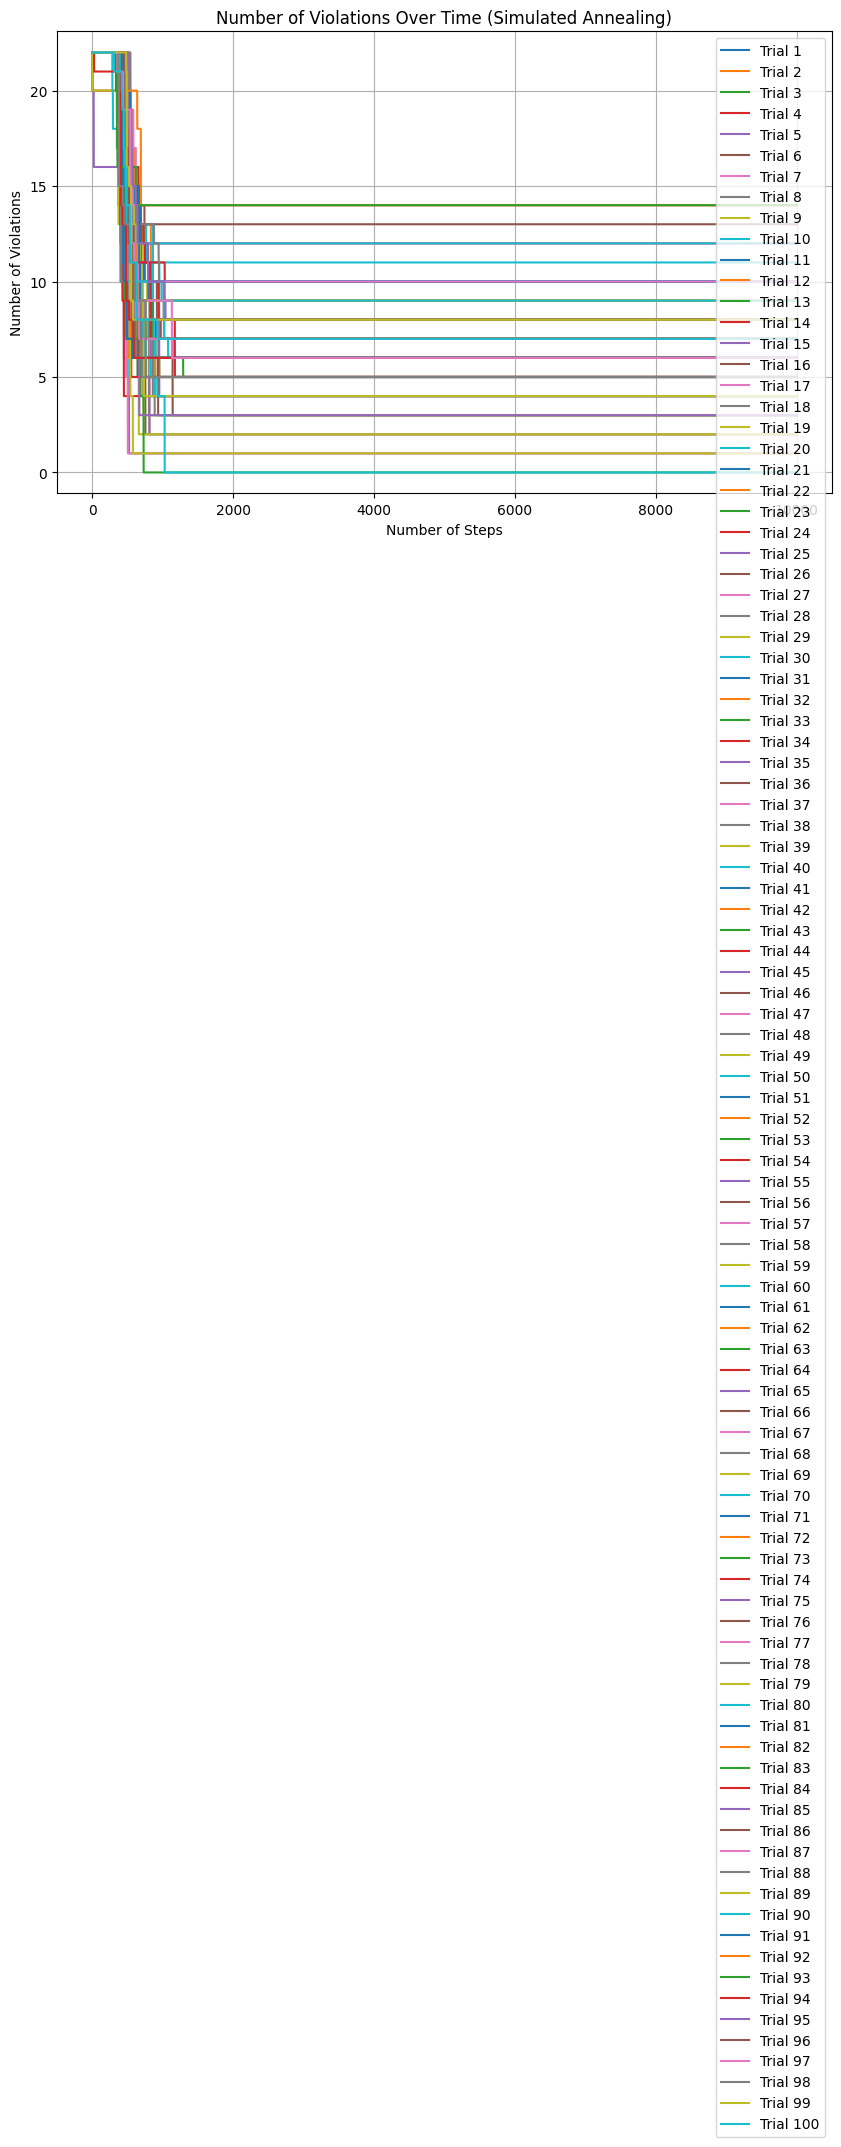

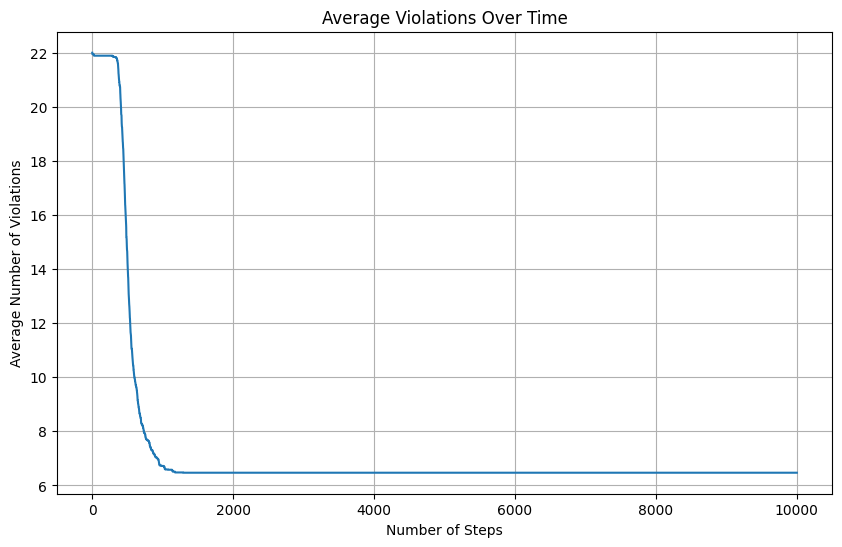

In [ ]:
import time
import matplotlib.pyplot as plt

def print_board(board):
    for row in board:
        print(' '.join(row))
    print()

def main():
    file_name = input("Enter the input file name: ")
    max_steps = int(input("Enter the maximum number of steps: "))
    num_trials = int(input("Enter the number of trials to run: "))
    results = []

    initial_board, n, m = decode_input(file_name)

    for trial in range(num_trials):
        # Determine fixed cells (already colored cells)
        fixed_cells = {(i, j) for i in range(n) for j in range(m) if initial_board[i][j] in {'b', 'w'}}

        t_init = 100.0
        t_final = 1e-4

        start_time = time.time()
        final_board, final_solution, violation_history, step_count = simulated_annealing(
            objective_function,
            initial_board,
            t_init,
            t_final,
            fixed_cells,
            max_steps
        )
        end_time = time.time()

        execution_time = end_time - start_time
        success = final_solution == 0  # If no violations, the solution is a success
        results.append({
            "trial": trial + 1,
            "success": success,
            "violations": final_solution,
            "steps": step_count,
            "time": execution_time,
            "violation_history": violation_history
        })

    generate_plots(results, max_steps)

def generate_plots(results, max_steps):
    plt.figure(figsize=(10, 6))
    for result in results:
        violation_history = result["violation_history"]
        if len(violation_history) < max_steps:
            # Pad the violation history with the last value if it's too short
            violation_history = violation_history + [violation_history[-1]] * (max_steps - len(violation_history))
        elif len(violation_history) > max_steps:
            # Trim violation history to max_steps length if it's too long
            violation_history = violation_history[:max_steps]

        plt.plot(range(max_steps), violation_history, label=f'Trial {result["trial"]}')

    plt.xlabel('Number of Steps')
    plt.ylabel('Number of Violations')
    plt.title('Number of Violations Over Time (Simulated Annealing)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Calculate the average violation history for all trials
    avg_violations = []
    for step in range(max_steps):
        step_violations = [result["violation_history"][step] if step < len(result["violation_history"]) else result["violation_history"][-1]
                           for result in results]
        avg_violations.append(sum(step_violations) / len(step_violations))

    # Plot the average violation history
    plt.figure(figsize=(10, 6))
    plt.plot(range(max_steps), avg_violations, label='Average Violations')
    plt.xlabel('Number of Steps')
    plt.ylabel('Average Number of Violations')
    plt.title('Average Violations Over Time')
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    main()

The quality of the solution, measured by the number of violations, improves significantly as the number of local steps increases. In the "Average Violations Over Time" plot, we observe that initially, the average number of violations remains high and fairly constant, indicating minimal improvement. However, around 1000 steps, there is a sharp decline in the number of violations, suggesting a significant enhancement in the solution quality. After this dramatic decrease, the number of violations stabilizes at a much lower level. Similarly, in the "Number of Violations Over Time (Simulated Annealing)" plot, each trial exhibits a similar pattern of high initial violations followed by a sudden drop around the same step count. This consistent behavior across multiple trials reinforces the observation that the most substantial improvement occurs around 1000 steps. The data does not indicate a qualitative difference in the improvement patterns for different trial sizes, as all trials demonstrate similar trends in violation reduction over time.


If we run the program with less steps, e.g for < 1000, we can observe that the number of violations increase significantly.

**P.S**:

When decreasing the temperature in a sigmoid way we couldn't get a valid solution, within all runs.
The best we could do was to get 1 violation:(

When using the t_current = t_current * 0.99 we got better results, so we kept that in the code, leaving the other in comments.

**Also**:

All the code was tested using the example provided in the exercise4.


Parts of the code are from: https://github.com/bnsreenu/python_for_microscopists/blob/master/319_what_is_simulated_annealing.ipynb